# Solar PV share sensitivity in Pathways

This notebook runs a PV-only `subshares` sensitivity for `SE - electricity - Solar PV Centralized` on the `remind-SSP2-PkBudg1000-stem-SPS1.zip` datapackage.

Technology narrative encoded in the YAML:

- `EUR`: faster shift from conventional c-Si to tandem perovskites, with moderate CIGS niches.
- `USA`: stronger CdTe penetration in utility-scale systems, plus some tandem and GaAs uptake.
- `CHA`: c-Si stays dominant longer, with a later but material tandem transition.

Implementation notes from the Pathways source:

- `subshares` is passed directly to `p.calculate(...)`.
- `subshare_groups=["PV"]` isolates the sensitivity to the PV subtechnology group.
- `use_distributions` must be greater than zero.
- For this analysis `remove_uncertainty=True` is used so the only Monte Carlo variability comes from the PV share sensitivity.
- The yearly Excel workbooks in `stats/` contain the sampled PV shares under the `Technology shares` sheet.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from pv_subshares_sensitivity_workflow import (
    DATAPACKAGE,
    SUBSHARES,
    REGIONS,
    PV_TECH_ORDER,
    initialize_pathways,
    get_years_and_scenario,
    get_production_volumes,
    get_share_trajectories,
    run_pathways_sensitivity,
    export_results,
    aggregate_lca_results,
    aggregate_exported_results,
    prepare_plot_data,
    make_figure,
)

ITERATIONS = 15
SEED = 42
EXPORT_BASE = Path("pv_subshares_sensitivity_results")
EXPORT_PATH = EXPORT_BASE.with_suffix(".gzip")
FIGURE_PATH = Path("pv_subshares_sensitivity_3x3.png")
REUSE_EXPORT = True

print("Datapackage:", DATAPACKAGE)
print("Subshares YAML:", SUBSHARES)
print("Reuse existing export:", REUSE_EXPORT)


/Users/romain/micromamba/envs/pathways/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


14:30:44+0100 - INFO - Using environment variable BRIGHTWAY2_DIR for data directory:
/Users/romain/Github/TA_Swiss/dev/.brightway-profile


Loading variables from /Users/romain/Github/TA_Swiss/dev/variables.yaml
USER_DATA_BASE_DIR: .pathways-user-data


14:30:44+0100 - WARNING - Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


Datapackage: /Users/romain/Library/CloudStorage/OneDrive-PaulScherrerInstitut/TA_Swiss/remind-SSP2-PkBudg1000-stem-SPS1.zip
Subshares YAML: pv_subshares_sensitivity.yaml
Reuse existing export: True


In [2]:
yaml.safe_load(SUBSHARES.read_text(encoding="utf-8"))


{'PV': {'_targets': [{'name': 'electricity production, photovoltaic, commercial',
    'reference product': 'electricity, low voltage',
    'unit': 'kilowatt hour'}],
  'c-Si': {'name': 'electricity production, photovoltaic, photovoltaic slanted-roof installation, 3 kWp, multi-Si, laminated, integrated',
   'reference product': 'electricity, low voltage',
   'unit': 'kilowatt hour',
   'share': {'EUR': {2005: {'loc': 0.944},
     2020: {'loc': 0.944},
     2050: {'minimum': 0.5, 'maximum': 0.65, 'uncertainty_type': 'uniform'},
     2100: {'minimum': 0.2, 'maximum': 0.35, 'uncertainty_type': 'uniform'}},
    'USA': {2005: {'loc': 0.944},
     2020: {'loc': 0.944},
     2050: {'minimum': 0.35, 'maximum': 0.5, 'uncertainty_type': 'uniform'},
     2100: {'minimum': 0.15, 'maximum': 0.3, 'uncertainty_type': 'uniform'}},
    'CHA': {2005: {'loc': 0.944},
     2020: {'loc': 0.944},
     2050: {'minimum': 0.6, 'maximum': 0.75, 'uncertainty_type': 'uniform'},
     2100: {'minimum': 0.4, 'maximum

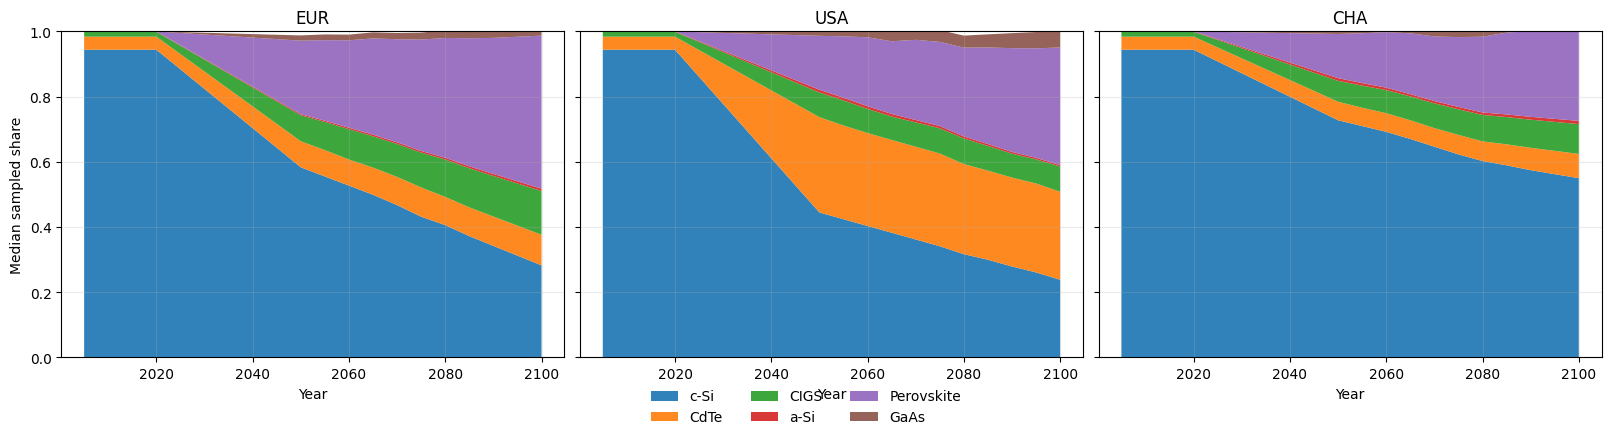

In [3]:
p0 = initialize_pathways(DATAPACKAGE)
years, scenario = get_years_and_scenario(p0)
production = get_production_volumes(p0, scenario)
shares = get_share_trajectories(years, ITERATIONS, subshares=SUBSHARES, seed=SEED)

share_summary = (
    shares.groupby(["region", "year", "technology"], as_index=False)["share"]
    .median()
)

fig, axes = plt.subplots(1, len(REGIONS), figsize=(16, 4), sharey=True, constrained_layout=True)
for ax, region in zip(axes, REGIONS):
    region_data = (
        share_summary.loc[share_summary["region"] == region]
        .pivot(index="year", columns="technology", values="share")
        .reindex(index=years, columns=PV_TECH_ORDER)
        .fillna(0.0)
    )
    ax.stackplot(region_data.index, region_data.to_numpy().T, labels=PV_TECH_ORDER, alpha=0.92)
    ax.set_title(region)
    ax.set_xlabel("Year")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Median sampled share")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.show()


In [4]:
if REUSE_EXPORT and EXPORT_PATH.exists():
    aggregated_results = aggregate_exported_results(EXPORT_PATH)
    print(f"Reusing {EXPORT_PATH}")
else:
    p, scenario, production, shares = run_pathways_sensitivity(
        datapackage=DATAPACKAGE,
        subshares=SUBSHARES,
        iterations=ITERATIONS,
        seed=SEED,
        multiprocessing=True,
    )
    EXPORT_PATH = export_results(p, EXPORT_BASE)
    aggregated_results = aggregate_lca_results(p)
    print(f"Exported to {EXPORT_PATH}")


Reusing pv_subshares_sensitivity_results.gzip


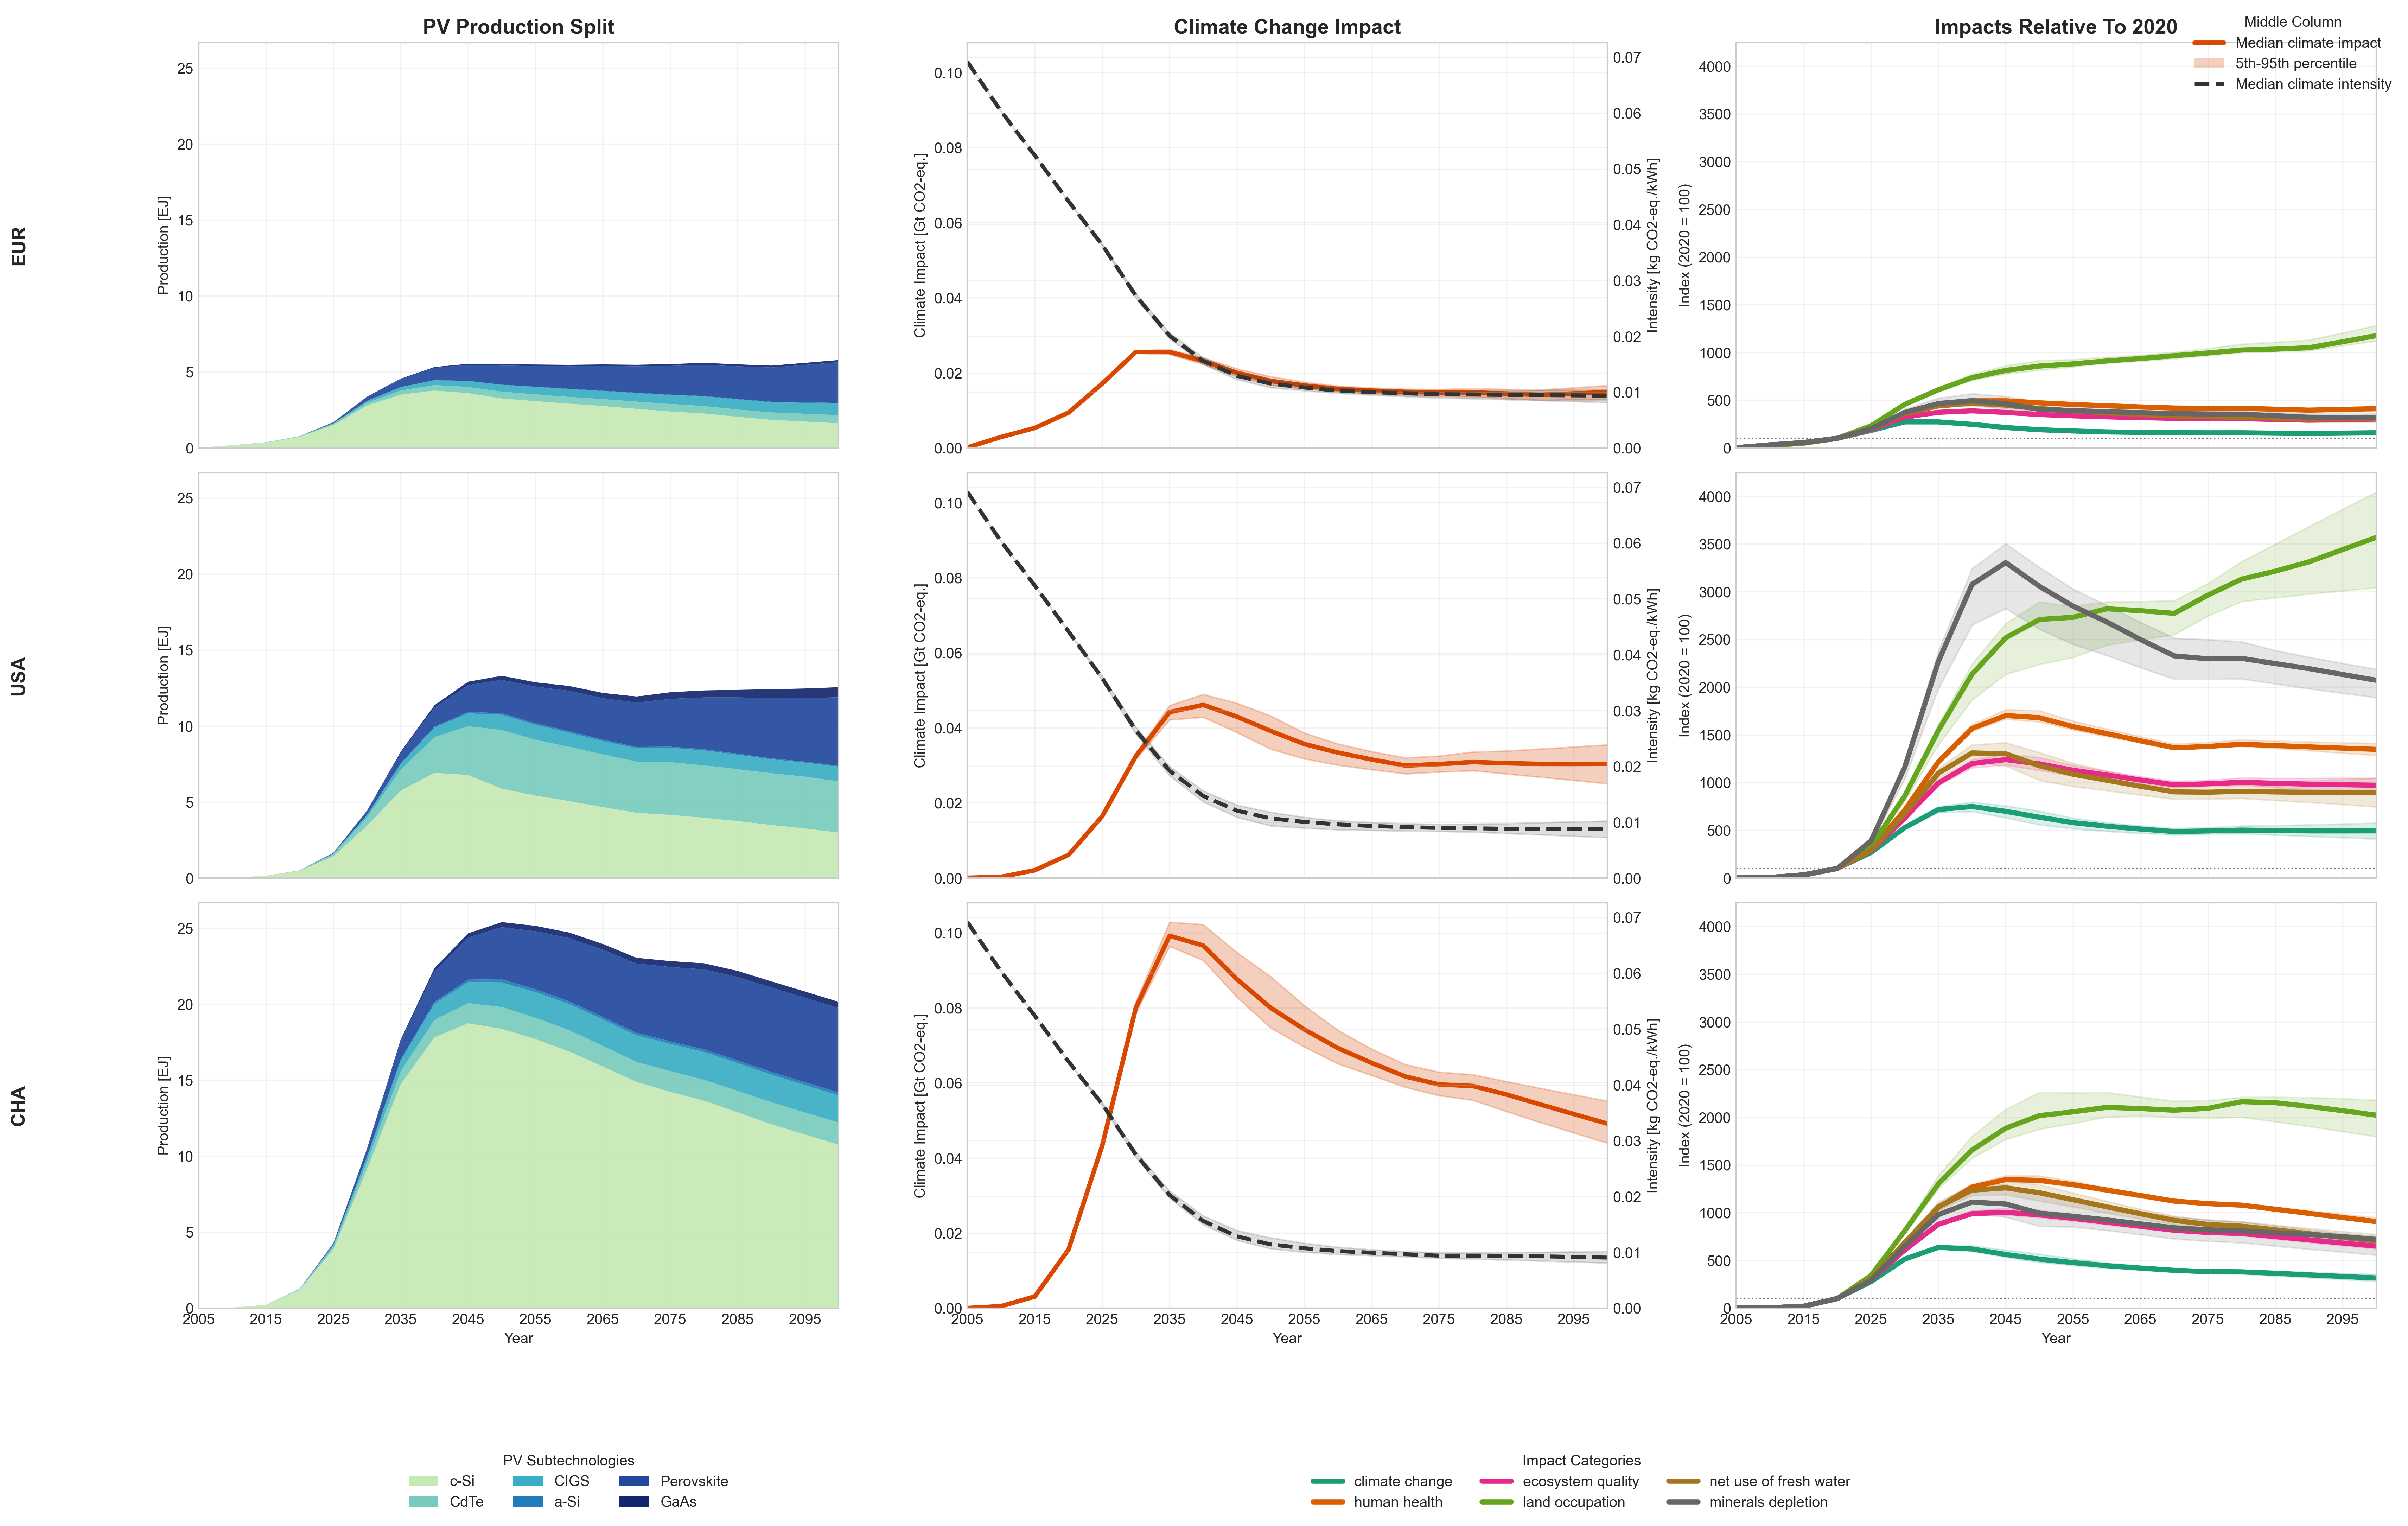

In [5]:
production_split, climate, indexed = prepare_plot_data(
    production=production,
    shares=shares,
    aggregated_results=aggregated_results,
)
make_figure(production_split, climate, indexed, FIGURE_PATH)
display(Image(filename=str(FIGURE_PATH)))


In [6]:
print("Exported results:", EXPORT_PATH)
print("Figure:", FIGURE_PATH)
sorted(Path("stats").glob("*.xlsx"))[-5:]


Exported results: pv_subshares_sensitivity_results.gzip
Figure: pv_subshares_sensitivity_3x3.png


[PosixPath('stats/remind_SSP2-PkBudg1000 - SPS1_2080.xlsx'),
 PosixPath('stats/remind_SSP2-PkBudg1000 - SPS1_2085.xlsx'),
 PosixPath('stats/remind_SSP2-PkBudg1000 - SPS1_2090.xlsx'),
 PosixPath('stats/remind_SSP2-PkBudg1000 - SPS1_2095.xlsx'),
 PosixPath('stats/remind_SSP2-PkBudg1000 - SPS1_2100.xlsx')]

In [7]:
technology_shares = pd.read_excel(
    Path("stats") / "remind_SSP2-PkBudg1000 - SPS1_2050.xlsx",
    sheet_name="Technology shares",
)
technology_shares.head()


,iteration,region,PV - c-Si,PV - CdTe,PV - CIGS,PV - a-Si,PV - Perovskite,PV - GaAs
0,1,CHA,0.714899,0.076571,0.076727,0.008497,0.112716,0.010589
1,2,CHA,0.673507,0.057791,0.059904,0.010000,0.180000,0.018798
2,3,CHA,0.672611,0.080000,0.065559,0.003546,0.172823,0.005461
3,4,CHA,0.738481,0.027932,0.043497,0.003885,0.178118,0.008087
4,5,CHA,0.681400,0.056817,0.080000,0.004029,0.162576,0.015179
